# 🔵 TẦNG 1 — DESCRIPTIVE ANALYTICS
## *"What happened?"* — Chuyện gì đã xảy ra?

> **Mục tiêu:** Mô tả tổng quan dữ liệu lương — phân phối, trung bình, các giá trị đặc trưng.  
> **Trả lời:**  
> - ❓ Câu hỏi 1: Mức lương trung bình của lập trình viên là bao nhiêu?  
> - ❓ Câu hỏi 2: Các vị trí khác nhau có mức lương khác nhau không?

---

## ⚙️ PHẦN 0: IMPORT & CHUẨN BỊ DỮ LIỆU

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize'   : (13, 6),
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')
PALETTE = sns.color_palette('husl', 12)
BLUE  = '#2563EB'
RED   = '#EF4444'
GREEN = '#10B981'

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


In [13]:
import pandas as pd

# ── Đọc dữ liệu ─────────────────────────────────────────────
df = pd.read_csv('salary_data.csv')

# ── Làm sạch tên cột ───────────────────────────────────────
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

# ── Xem các cột hiện có ────────────────────────────────────
print("Các cột trong dataset:")
print(df.columns.tolist())

# ── Xóa dữ liệu trùng ──────────────────────────────────────
df = df.drop_duplicates()

# ── Ưu tiên chọn đúng cột lương ────────────────────────────
preferred_salary_cols = [
    'salary_in_usd',
    'salary',
    'annual_salary',
    'pay',
    'income',
    'wage'
]

SAL_COL = next(
    (c for c in preferred_salary_cols if c in df.columns),
    None
)

# ── Nếu không tìm thấy ─────────────────────────────────────
if SAL_COL is None:
    raise ValueError("❌ Không tìm thấy cột lương")

print(f'\n✅ Cột lương được chọn: {SAL_COL}')

# ── Chuyển dữ liệu sang số ─────────────────────────────────
df[SAL_COL] = (
    df[SAL_COL]
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .str.strip()
)

# Ép kiểu numeric an toàn
df[SAL_COL] = pd.to_numeric(
    df[SAL_COL],
    errors='coerce'
)

# ── Xóa dòng lỗi ───────────────────────────────────────────
df = df.dropna(subset=[SAL_COL])

# ── Kiểm tra kiểu dữ liệu ──────────────────────────────────
print("\nKiểu dữ liệu:")
print(df[SAL_COL].dtype)

# ── Loại outlier ───────────────────────────────────────────
q01 = df[SAL_COL].quantile(0.01)
q99 = df[SAL_COL].quantile(0.99)

df = df[
    (df[SAL_COL] >= q01) &
    (df[SAL_COL] <= q99)
]

# ── Điền missing value ─────────────────────────────────────
for col in df.columns:

    if df[col].isnull().sum() > 0:

        if pd.api.types.is_numeric_dtype(df[col]):

            df[col] = df[col].fillna(
                df[col].median()
            )

        else:

            df[col] = df[col].fillna(
                df[col].mode()[0]
            )

# ── Kết quả ────────────────────────────────────────────────
print(f'\n✅ Dữ liệu sẵn sàng:')
print(f'Số dòng: {df.shape[0]:,}')
print(f'Số cột : {df.shape[1]}')

print("\n5 dòng đầu:")
print(df.head())

Các cột trong dataset:
['rating', 'company_name', 'job_title', 'salary', 'salaries_reported', 'location', 'employment_status', 'job_roles']

✅ Cột lương được chọn: salary

Kiểu dữ liệu:
int64

✅ Dữ liệu sẵn sàng:
Số dòng: 22,355
Số cột : 8

5 dòng đầu:
   rating                      company_name          job_title   salary  \
0     3.8                            Sasken  Android Developer   400000   
1     4.5  Advanced Millennium Technologies  Android Developer   400000   
2     4.0                         Unacademy  Android Developer  1000000   
3     3.8                SnapBizz Cloudtech  Android Developer   300000   
4     4.4            Appoids Tech Solutions  Android Developer   600000   

   salaries_reported   location employment_status job_roles  
0                  3  Bangalore         Full Time   Android  
1                  3  Bangalore         Full Time   Android  
2                  3  Bangalore         Full Time   Android  
3                  3  Bangalore         Full Tim

---
## 📌 PHẦN 1: THỐNG KÊ MÔ TẢ
### ❓ Câu hỏi 1: Mức lương trung bình của lập trình viên là bao nhiêu?

In [14]:
# Tạo biến sal
sal = df[SAL_COL]

# Đảm bảo numeric
sal = pd.to_numeric(sal, errors='coerce')

# Xóa NaN
sal = sal.dropna()

print('=' * 55)
print('THỐNG KÊ MÔ TẢ MỨC LƯƠNG')
print('=' * 55)

stats_dict = {
    'Số mẫu'                  : f'{len(sal):,}',
    'Trung bình (Mean)'       : f'${sal.mean():>12,.0f}',
    'Trung vị (Median)'       : f'${sal.median():>12,.0f}',
    'Độ lệch chuẩn (Std)'     : f'${sal.std():>12,.0f}',
    'Thấp nhất (Min)'         : f'${sal.min():>12,.0f}',
    'Phân vị 25% (Q1)'        : f'${sal.quantile(0.25):>12,.0f}',
    'Phân vị 75% (Q3)'        : f'${sal.quantile(0.75):>12,.0f}',
    'Cao nhất (Max)'          : f'${sal.max():>12,.0f}',
    'IQR (Q3 - Q1)'           : f'${sal.quantile(0.75)-sal.quantile(0.25):>12,.0f}',
    'Độ lệch (Skewness)'      : f'{sal.skew():>12.4f}',
    'Độ nhọn (Kurtosis)'      : f'{sal.kurtosis():>12.4f}',
}

for k, v in stats_dict.items():
    print(f'   {k:<30}: {v}')

sk = sal.skew()

print(f'\n💡 Nhận xét Skewness = {sk:.2f} → ', end='')

if sk > 0.5:
    print('Phân phối LỆCH PHẢI')

elif sk < -0.5:
    print('Phân phối LỆCH TRÁI')

else:
    print('Phân phối gần CHUẨN')

THỐNG KÊ MÔ TẢ MỨC LƯƠNG
   Số mẫu                        : 22,355
   Trung bình (Mean)             : $     660,149
   Trung vị (Median)             : $     500,000
   Độ lệch chuẩn (Std)           : $     519,942
   Thấp nhất (Min)               : $      72,000
   Phân vị 25% (Q1)              : $     300,000
   Phân vị 75% (Q3)              : $     900,000
   Cao nhất (Max)                : $   3,100,000
   IQR (Q3 - Q1)                 : $     600,000
   Độ lệch (Skewness)            :       1.6447
   Độ nhọn (Kurtosis)            :       3.0646

💡 Nhận xét Skewness = 1.64 → Phân phối LỆCH PHẢI


---
## 📊 PHẦN 2: PHÂN PHỐI LƯƠNG

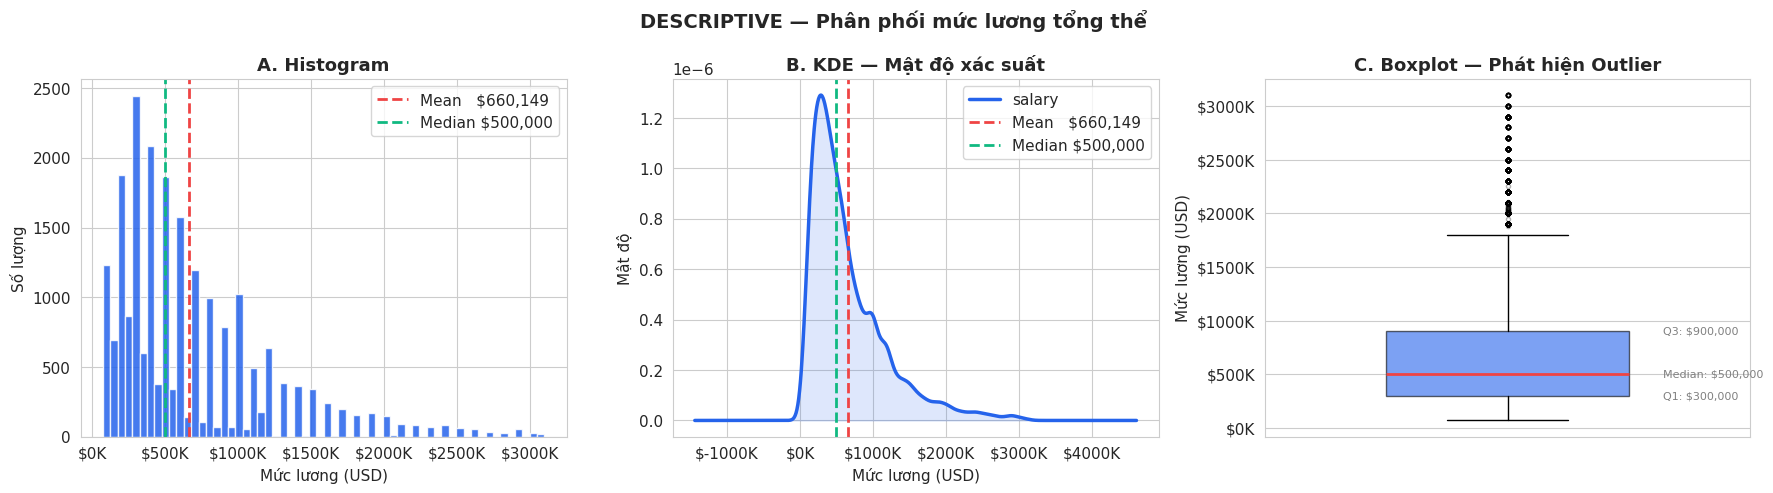

💾 Lưu: desc_01_salary_distribution.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DESCRIPTIVE — Phân phối mức lương tổng thể', fontsize=14, fontweight='bold')

# [A] Histogram
ax = axes[0]
ax.hist(sal, bins=60, color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(sal.mean(),   color=RED,   linestyle='--', lw=2, label=f'Mean   ${sal.mean():,.0f}')
ax.axvline(sal.median(), color=GREEN, linestyle='--', lw=2, label=f'Median ${sal.median():,.0f}')
ax.set_title('A. Histogram')
ax.set_xlabel('Mức lương (USD)')
ax.set_ylabel('Số lượng')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax.legend()

# [B] KDE
ax = axes[1]
sal.plot.kde(ax=ax, color=BLUE, lw=2.5)
ax.axvline(sal.mean(),   color=RED,   linestyle='--', lw=2, label=f'Mean   ${sal.mean():,.0f}')
ax.axvline(sal.median(), color=GREEN, linestyle='--', lw=2, label=f'Median ${sal.median():,.0f}')
ax.fill_between(ax.lines[0].get_xdata(), ax.lines[0].get_ydata(), alpha=0.15, color=BLUE)
ax.set_title('B. KDE — Mật độ xác suất')
ax.set_xlabel('Mức lương (USD)')
ax.set_ylabel('Mật độ')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax.legend()

# [C] Boxplot
ax = axes[2]
ax.boxplot(sal, vert=True, patch_artist=True, widths=0.5,
           boxprops=dict(facecolor=BLUE, alpha=0.6),
           medianprops=dict(color=RED, lw=2),
           flierprops=dict(marker='o', markersize=3, alpha=0.3))
ax.set_title('C. Boxplot — Phát hiện Outlier')
ax.set_ylabel('Mức lương (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax.set_xticks([])
for q, lbl in [(0.25,'Q1'),(0.5,'Median'),(0.75,'Q3')]:
    ax.text(1.32, sal.quantile(q), f'{lbl}: ${sal.quantile(q):,.0f}',
            va='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('desc_01_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Lưu: desc_01_salary_distribution.png')

---
## 📊 PHẦN 3: LƯƠNG THEO VỊ TRÍ CÔNG VIỆC
### ❓ Câu hỏi 2: Các vị trí khác nhau có mức lương khác nhau không?

In [16]:
# Tự động phát hiện cột vị trí
job_kw = ['job','title','role','position','designation']
JOB_COL = next((c for c in df.columns if any(k in c for k in job_kw)), None)
print(f'📌 Cột vị trí: "{JOB_COL}"')
# ⚠️ Sửa nếu sai: JOB_COL = 'ten_cot_thuc_te'

if JOB_COL:
    job_stats = (df.groupby(JOB_COL)[SAL_COL]
                 .agg(count='count', mean='mean', median='median', std='std')
                 .sort_values('mean', ascending=False)
                 .reset_index())
    print(f'\n📊 Có {len(job_stats)} vị trí khác nhau')
    print(f'\nTop 15 vị trí lương cao nhất:')
    print(job_stats.head(15)[[JOB_COL,'count','mean','median']].to_string(index=False))

📌 Cột vị trí: "job_title"

📊 Có 1051 vị trí khác nhau

Top 15 vị trí lương cao nhất:
                                        job_title  count      mean    median
         Software Development Engineer II In Test      1 2900000.0 2900000.0
        Software Development Engineer In Test, II      1 2900000.0 2900000.0
      Senior Software Engineer (Development Lead)      1 2800000.0 2800000.0
               Software Development Engineer - II      1 2800000.0 2800000.0
              Software Development Engineer Staff      1 2800000.0 2800000.0
          Amazon Software Development Engineer II      1 2800000.0 2800000.0
      Sr IT Software Development Engineer in Test      1 2700000.0 2700000.0
              IT Software Development Engineer II      1 2700000.0 2700000.0
                Consultant Database Administrator      1 2700000.0 2700000.0
                 Sr Oracle Database Administrator      1 2600000.0 2600000.0
                            Front End Engineer II      1 2600000.0 2

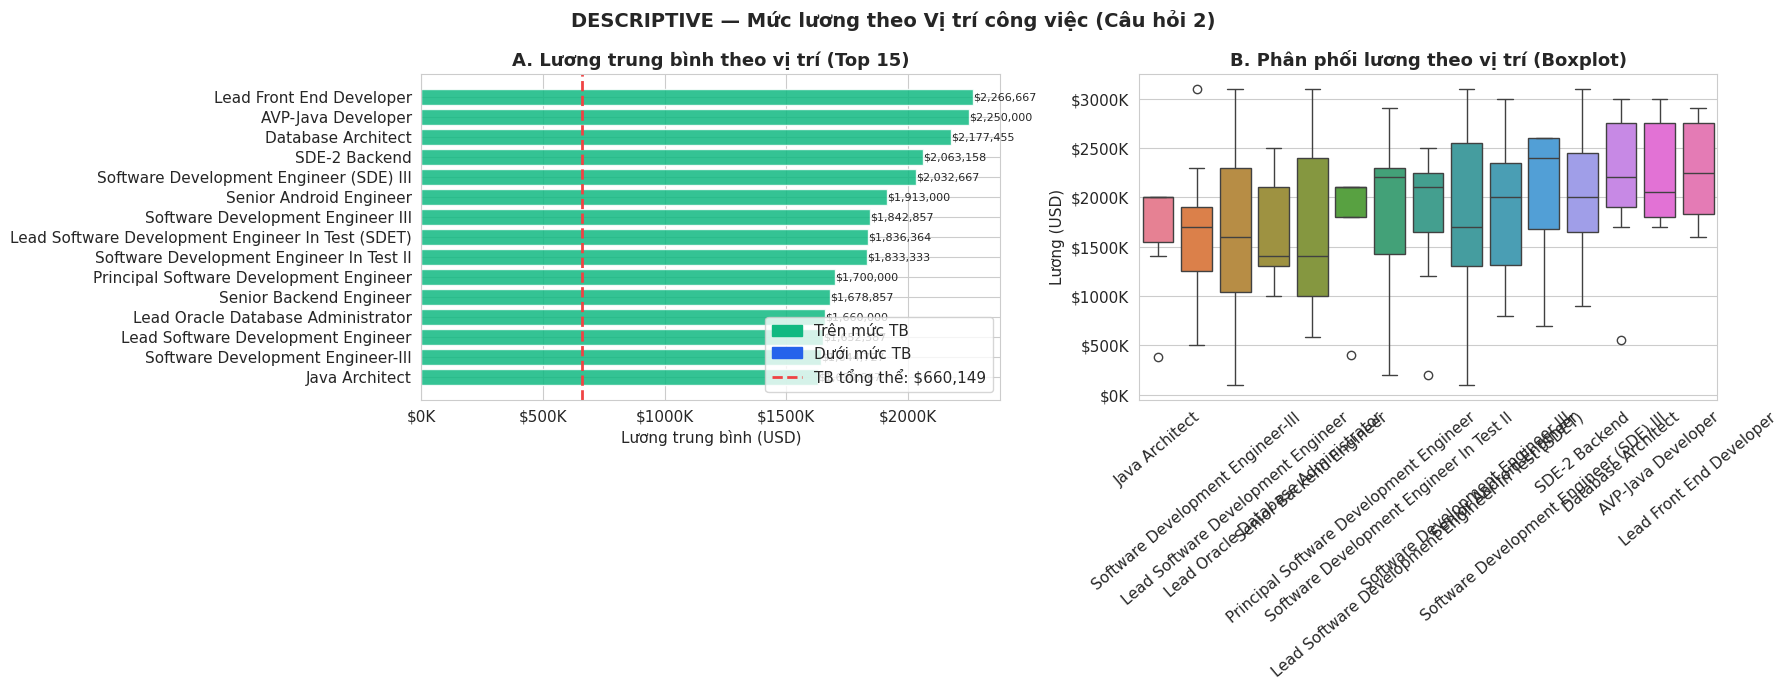

💾 Lưu: desc_02_salary_by_job.png


In [17]:
if JOB_COL:
    top15 = job_stats[job_stats['count'] >= 5].head(15).sort_values('mean')

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('DESCRIPTIVE — Mức lương theo Vị trí công việc (Câu hỏi 2)',
                 fontsize=14, fontweight='bold')

    # [A] Barplot ngang
    ax = axes[0]
    colors_bar = [GREEN if m >= sal.mean() else BLUE for m in top15['mean']]
    bars = ax.barh(top15[JOB_COL], top15['mean'],
                   color=colors_bar, edgecolor='white', alpha=0.85)
    ax.axvline(sal.mean(), color=RED, linestyle='--', lw=2,
               label=f'TB tổng thể: ${sal.mean():,.0f}')
    for bar, val in zip(bars, top15['mean']):
        ax.text(val + 300, bar.get_y() + bar.get_height()/2,
                f'${val:,.0f}', va='center', fontsize=8)
    ax.set_title('A. Lương trung bình theo vị trí (Top 15)')
    ax.set_xlabel('Lương trung bình (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
    p1 = mpatches.Patch(color=GREEN, label='Trên mức TB')
    p2 = mpatches.Patch(color=BLUE,  label='Dưới mức TB')
    ax.legend(handles=[p1, p2, ax.lines[0]], loc='lower right')

    # [B] Boxplot nhóm
    ax = axes[1]
    plot_data = df[df[JOB_COL].isin(top15[JOB_COL].tolist())]
    order = top15[JOB_COL].tolist()
    sns.boxplot(data=plot_data, x=JOB_COL, y=SAL_COL,
                order=order, palette='husl', ax=ax)
    ax.set_title('B. Phân phối lương theo vị trí (Boxplot)')
    ax.set_xlabel('')
    ax.set_ylabel('Lương (USD)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
    ax.tick_params(axis='x', rotation=40)

    plt.tight_layout()
    plt.savefig('desc_02_salary_by_job.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Lưu: desc_02_salary_by_job.png')

---
## ✅ KẾT LUẬN TẦNG 1 — DESCRIPTIVE

### Câu hỏi 1 — Mức lương trung bình:
- **Mean** ** | **Median** **
- Phân phối lệch phải → **Median** phản ánh thực tế chính xác hơn Mean
- Khoảng lương phổ biến (IQR): ****

### Câu hỏi 2 — Chênh lệch theo vị trí:
- **CÓ** sự chênh lệch rõ rệt về lương giữa các vị trí
- Senior / Lead / Manager có lương cao hơn đáng kể so với Junior / Entry-level

➡️ **Tiếp theo: `02_diagnostic.ipynb`**